In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
pd.read_csv(r"C:\Users\HP\Downloads\CTG.csv")

,LB,AC,FM,NSP
0,120,0.000,0.000,2
1,132,0.006,0.000,1
2,133,0.003,0.000,1
3,134,0.003,0.000,1
4,132,0.007,0.000,1
...,...,...,...,...
2121,140,0.000,0.000,2
2122,140,0.001,0.000,2
2123,140,0.001,0.000,2
2124,140,0.001,0.000,2


In [5]:
ctg=pd.read_csv(r"C:\Users\HP\Downloads\CTG.csv")

In [6]:
ctg.isnull().sum()[ctg.isnull().sum()>0]

Series([], dtype: int64)

In [7]:
from sklearn.model_selection import train_test_split
ctg_train,ctg_test=train_test_split(ctg,test_size=.2)

In [8]:
ctg.NSP.value_counts()

NSP
1    1655
2     295
3     176
Name: count, dtype: int64

In [9]:
#over sampling
df2=ctg_train[ctg_train.NSP==2]
df3=ctg_train[ctg_train.NSP==3]
ctg_train=pd.concat([ctg_train,df3,df3,df3,df3,df2])

In [10]:
ctg_train_x=ctg_train.iloc[:,0:-1]
ctg_train_y=ctg_train.iloc[:,-1]

ctg_test_x=ctg_test.iloc[:,0:-1]
ctg_test_y=ctg_test.iloc[:,-1]

In [11]:
ctg_test_y

80      1
1561    1
204     1
1474    2
657     1
       ..
542     1
1196    1
2090    1
885     1
767     3
Name: NSP, Length: 426, dtype: int64

In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=37)

In [13]:
knn.fit(ctg_train_x,ctg_train_y)

,n_neighbors,37
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
pred_knn=knn.predict(ctg_test_x)

In [15]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [16]:
tab_knn=confusion_matrix(ctg_test_y,pred_knn)

In [17]:
tab_knn

array([[256,  23,  57],
       [ 20,  27,  12],
       [  8,   4,  19]])

In [18]:
#tab_knn.diagonal().sum()/tab_knn.sum()
accuracy_score(ctg_test_y,pred_knn)

0.7089201877934272

In [19]:
print(classification_report(ctg_test_y,pred_knn))

              precision    recall  f1-score   support

           1       0.90      0.76      0.83       336
           2       0.50      0.46      0.48        59
           3       0.22      0.61      0.32        31

    accuracy                           0.71       426
   macro avg       0.54      0.61      0.54       426
weighted avg       0.80      0.71      0.74       426



In [20]:
l1=[]
for k in range(1,100):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(ctg_train_x,ctg_train_y)
    pred_knn=knn.predict(ctg_test_x)
    tab_knn=confusion_matrix(ctg_test_y,pred_knn)
    acc=accuracy_score(ctg_test_y,pred_knn)
    l1.append(acc)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

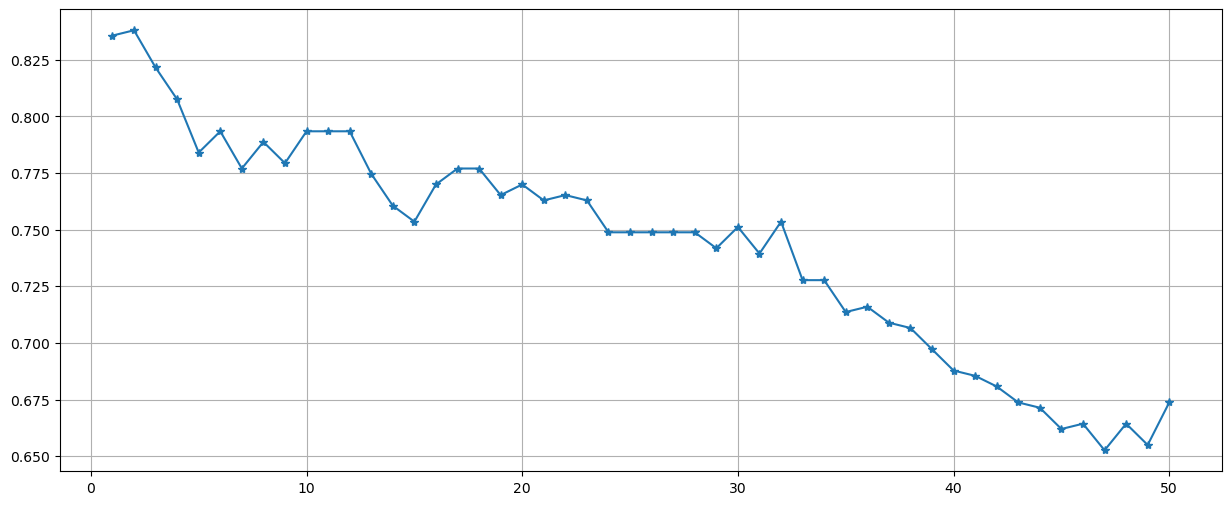

In [22]:
plt.figure(figsize=(15,6))
plt.plot(list(range(1, 51)), l1[:50], marker='*')
plt.grid()

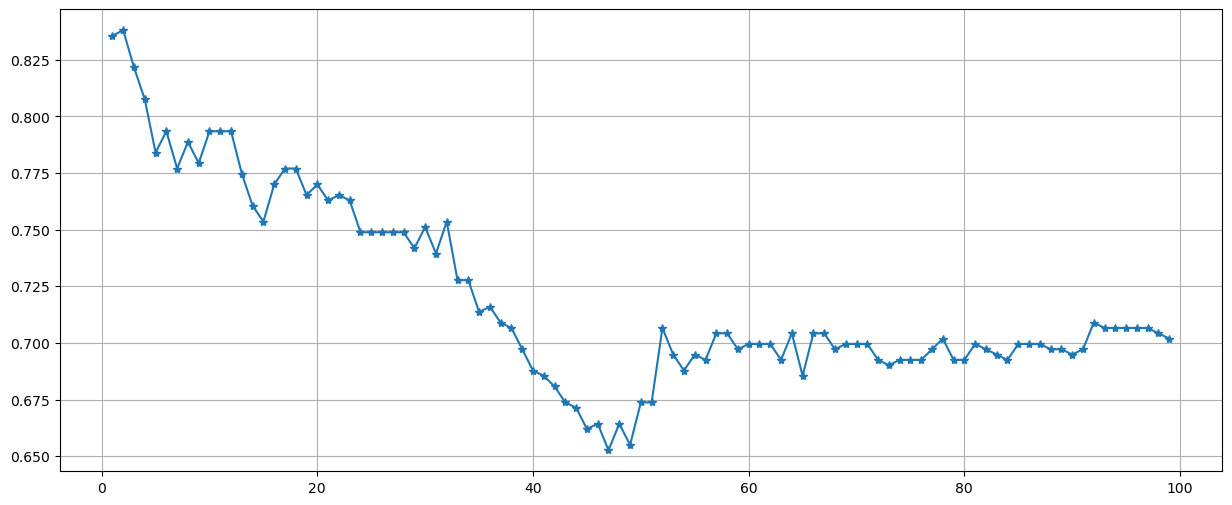

In [23]:
plt.figure(figsize=(15,6))
plt.plot(list(range(1,100)), l1, marker='*')
plt.grid()

# Feature Selection

In [24]:
import pandas as pd

# Boruta

In [25]:
pd.read_csv(r"C:\Users\HP\Downloads\CreditRisk59.csv")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,4.0,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,Y
977,LP002975,Male,Yes,0.0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,Y
978,LP002980,Male,No,0.0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,Y
979,LP002986,Male,Yes,0.0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,N


In [26]:
cr=pd.read_csv(r"C:\Users\HP\Downloads\CreditRisk59.csv")

In [27]:
cr.isnull().sum()[cr.isnull().sum()>0]

Gender              24
Married              3
Dependents          25
Self_Employed       55
LoanAmount          27
Loan_Amount_Term    20
Credit_History      79
dtype: int64

In [28]:
cr.Gender.fillna('Male', inplace = True)
cr. Married. fillna('Yes', inplace = True)
cr. Dependents. fillna(0, inplace = True)
cr. LoanAmount.fillna(cr.LoanAmount.mean(), inplace = True)
cr. Loan_Amount_Term.fillna(cr.Loan_Amount_Term.mean(), inplace = True)
cr. Credit_History. fillna(0, inplace = True)
cr.Self_Employed.fillna('No', inplace= True)

In [29]:
cr.select_dtypes(include='object').columns

Index(['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [31]:
cr[cr.select_dtypes(include='object').columns] = cr[cr.select_dtypes(include='object').columns].apply(le.fit_transform)

In [32]:
cr=cr.drop(['Loan_ID'],axis=1)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import numpy as np

In [34]:
cr_x = cr.iloc[:, 0:11]
cr_x1 = cr.iloc[:, 0:11] # just a back up
cr_y = cr.iloc[:, -1]

In [35]:
cr_x = np.array(cr_x)
cr_y = np.array(cr_y)
cr_y

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,

In [36]:
rf = RandomForestClassifier()
boruta_Feature_selector = BorutaPy(rf, max_iter = 25, verbose = 2)
boruta_Feature_selector.fit(cr_x, cr_y)

Iteration: 	1 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	2 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	3 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	4 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	5 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	6 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	7 / 25
Confirmed: 	0
Tentative: 	11
Rejected: 	0
Iteration: 	8 / 25
Confirmed: 	1
Tentative: 	2
Rejected: 	8
Iteration: 	9 / 25
Confirmed: 	1
Tentative: 	2
Rejected: 	8
Iteration: 	10 / 25
Confirmed: 	1
Tentative: 	2
Rejected: 	8
Iteration: 	11 / 25
Confirmed: 	1
Tentative: 	2
Rejected: 	8
Iteration: 	12 / 25
Confirmed: 	2
Tentative: 	1
Rejected: 	8
Iteration: 	13 / 25
Confirmed: 	2
Tentative: 	1
Rejected: 	8
Iteration: 	14 / 25
Confirmed: 	2
Tentative: 	1
Rejected: 	8
Iteration: 	15 / 25
Confirmed: 	2
Tentative: 	1
Rejected: 	8
Iteration: 	16 / 25
Confirmed: 	2
Tentative: 	1
Rejected: 	8
Iteration: 	17 / 25
Confir

,estimator,RandomForestC...0x2153C6F3C40)
,n_estimators,1000
,perc,100
,alpha,0.05
,two_step,True
,max_iter,25
,random_state,RandomState(M... 0x2153C6F3C40
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,n_estimators,1000


In [37]:
boruta_Feature_selector.support_

array([False, False, False, False, False,  True, False, False, False,
        True, False])

In [38]:
cr_x1.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [39]:
feat_imp = pd.DataFrame()
feat_imp['Features'] = cr_x1.columns
feat_imp['imp'] = boruta_Feature_selector.support_

In [40]:
feat_imp = feat_imp.sort_values('imp', ascending = False)

In [41]:
feat_imp

,Features,imp
5,ApplicantIncome,True
9,Credit_History,True
0,Gender,False
1,Married,False
2,Dependents,False
3,Education,False
4,Self_Employed,False
6,CoapplicantIncome,False
7,LoanAmount,False
8,Loan_Amount_Term,False
